# WNTR Chlorine — 5 Learning Exercises

**配套 supervisor 的 `wntr_chlorine_getting_started.ipynb` (§7)**

| 练习 | 主题 | 你要学到什么 | 对论文的价值 |
|------|-----|------------|--------------|
| 1 | Bulk vs Wall | 拆解余氯损失：水体衰减 vs 壁面衰减 | 论证为什么必须同时校准 k_b, k_w |
| 2 | Boundary scaling | 入口浓度 vs 下游浓度的线性关系 | 论证 inlet C(t) 作为边界条件的合理性 |
| 3 | Mass transfer | 减半管径 → 壁面衰减加剧 | 解释 DMA 间异质性的物理来源 |
| 4 | Time-varying inlet | 给源头加时变 pattern | 这是 Bristol 真实建模必备 |
| 5 | Brute-force calibrator | 网格搜索找最优 (k_b, k_w) | GLUE/Bayesian 之前的"裸"基线 |

> **怎么用这个 notebook**：每个练习有 3 部分
> 1. **题目** （markdown，包含中文解释 + 学习目标 + 提示）
> 2. **骨架代码** （含 `# TODO`，你来填空）
> 3. **思考** （markdown，做完后用一两句话总结你的发现）
>
> 卡住时滚动到下面"💡 提示展开"区。


## 0 · Setup（环境 + 复用 supervisor 的核心函数）

把 `simulate_chlorine()` 重写在这里，并加一个 `pre_run` 钩子：
练习 3、4 需要在仿真前修改 `wn`，这个钩子让你不用改函数本体。


In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import wntr

PRACTICE_INP = os.path.join(os.path.dirname(wntr.__file__), 'library', 'networks', 'Net3.inp')
MONITOR_NODES = ['10', '15', '20', '35', '40', '60']
INLET_CHLORINE_MGL = 1.0
SECONDS_PER_DAY = 24 * 3600

def per_day_to_per_second(v):
    return v / SECONDS_PER_DAY

def simulate_chlorine(kb_per_day, kw_per_day,
                      monitor_nodes=None,
                      inp_file=PRACTICE_INP,
                      inlet_mgl=INLET_CHLORINE_MGL,
                      duration_hours=48,
                      pre_run=None):
    """
    Single chlorine simulation.
    pre_run : optional callable(wn) -> None
              Modify the wn object before simulation (used in Ex 3 & 4).
    Returns : DataFrame (index=hours, cols=monitor IDs, units mg/L)
    """
    if monitor_nodes is None:
        monitor_nodes = MONITOR_NODES
    wn = wntr.network.WaterNetworkModel(inp_file)
    wn.options.time.duration           = duration_hours * 3600
    wn.options.time.hydraulic_timestep = 3600
    wn.options.time.report_timestep    = 3600
    wn.options.time.quality_timestep   = 300
    wn.options.quality.parameter     = 'CHEMICAL'
    wn.options.quality.chemical_name = 'Chlorine'
    wn.options.quality.inpfile_units = 'mg/L'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.reaction.bulk_coeff = per_day_to_per_second(kb_per_day)
    wn.options.reaction.wall_coeff = per_day_to_per_second(kw_per_day)
    for r in wn.reservoir_name_list:
        wn.get_node(r).initial_quality = inlet_mgl

    if pre_run is not None:
        pre_run(wn)

    res = wntr.sim.EpanetSimulator(wn).run_sim()
    q = res.node['quality'][monitor_nodes]
    q.index = q.index / 3600.0
    q.index.name = 'hours'
    return q

# Sanity check
ts0 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
print('shape:', ts0.shape)
ts0.tail(3).round(3)


/opt/anaconda3/envs/cive70058/lib/python3.11/site-packages/wntr/epanet/toolkit.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


shape: (49, 6)


name,10,15,20,35,40,60
hours,,,,,,
46.0,0.863,0.266,0.100,0.685,0.164,1.000
47.0,0.845,0.081,0.832,0.650,0.164,0.998
48.0,0.828,0.079,0.831,0.713,0.161,0.998


---
## 练习 1 · Bulk vs Wall：余氯到底是被谁"消耗"的？

> **导师原题**: Re-run with `kw = 0`. How much of Net3's residual loss is bulk vs wall? Relate to Hallam et al. (2002).

### 中文背景
- **水体衰减 (k_b)**：水里有机物、还原性物质和氯反应（实验室 bottle test 可测）
- **壁面衰减 (k_w)**：管壁上的生物膜/腐蚀/沉积物和氯反应（**必须**靠管网数据校准——这是你 thesis 的核心未知数）
- Hallam et al. 2002 通过现场实验区分了两者贡献——你这里用模拟做同样的事

### 学习目标
1. 用代码量化"壁面衰减占总损失的百分比"
2. 找出哪个监测点壁面贡献最大（→ 这是校准 k_w 最有用的测点）

### 任务
1. 用 `(k_b=-0.5, k_w=0)` 跑一次——**只有水体衰减**
2. 用 `(k_b=-0.5, k_w=-0.1)` 跑一次——水体 + 壁面（基线）
3. 对每个监测点，计算稳态浓度（取最后 24 h 均值）
4. 计算：
   - `loss_bulk_pct = (1 - C_bulkonly / 1.0) × 100`
   - `loss_wall_pct = (C_bulkonly - C_both) / 1.0 × 100`
5. 哪个点壁面占比最大？

### 提示
- 取稳态：`ts.iloc[-24:].mean()` 拿到每列后 24 h 均值（Series）
- 输出为 pd.DataFrame 方便阅读


In [ ]:
# === 你的代码 ===

# Step 1: 只有水体衰减
ts_bulk_only = simulate_chlorine(kb_per_day=-0.5, kw_per_day=0.0)

# Step 2: 水体 + 壁面（基线）
# TODO: 调用 simulate_chlorine 设 kb=-0.5, kw=-0.1
ts_both = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)

# Step 3: 取稳态（最后 24 h 均值）
mean_bulk = ts_bulk_only.iloc[-24:].mean()
# TODO: 算 ts_both 的稳态
mean_both = ts_both.iloc[-24:].mean()

# Step 4: 计算百分比
# TODO: 损失百分比
inlet = 1.0
loss_bulk_pct = (inlet - mean_bulk) / inlet * 100
loss_wall_pct = (mean_bulk - mean_both) / inlet * 100

# Step 5: 制表
table = pd.DataFrame({
    'C  bulk-only (mg/L)' : mean_bulk.round(3),
    'C  bulk+wall (mg/L)' : mean_both.round(3) if isinstance(mean_both, pd.Series) else None,
    'loss_bulk (%)'       : loss_bulk_pct.round(1),
    'loss_wall (%)'       : loss_wall_pct.round(1) if isinstance(loss_wall_pct, pd.Series) else None,
})
table


,C bulk-only (mg/L),C bulk+wall (mg/L),loss_bulk (%),loss_wall (%)
name,,,,
10,0.956,0.955,4.400000,0.0
15,0.619,0.470,38.099998,14.9
20,0.482,0.440,51.799999,4.1
35,0.815,0.727,18.500000,8.8
40,0.629,0.541,37.099998,8.8
60,0.999,0.997,0.100000,0.1


### 💡 提示（点击展开 / 翻到下面）

<details>
<summary>填空答案</summary>

```python
ts_both   = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
mean_both = ts_both.iloc[-24:].mean()
```
</details>

### ✏️ 你的发现（写一两句）
- 哪个监测点壁面占比最大？_______________
- 这个点离 reservoir 远还是近？这意味着什么？_______________
- 如果你只有这 6 个监测点，校准 k_w 时优先用哪些？_______________


---
## 练习 2 · Boundary Scaling：入口翻倍，下游也翻倍吗？

> **导师原题**: Change `INLET_CHLORINE_MGL` and confirm residuals scale ~linearly. Why does that matter for treating the inlet monitor as a boundary condition?

### 中文背景
一阶动力学：`dC/dt = -k·C`，解为 `C(t) = C₀·exp(-k·t)`。
**注意 C₀ 是乘性因子**——所以如果 C₀ 变 2 倍，下游所有点也应该变 2 倍。

### 学习目标
- 验证一阶动力学的"齐次性"（homogeneity）
- 理解为什么 Bristol 项目可以把 DMA inlet 的测量值"直接喂进"模型作边界——因为系统响应是线性的，不需要重新校准

### 任务
1. 用 4 个不同的入口浓度跑：`C₀ ∈ {0.5, 1.0, 1.5, 2.0}` mg/L
2. 固定 `k_b=-0.5, k_w=-0.1`
3. 对一个监测点（例如 node 20），画出 4 条时间序列
4. 把每条曲线**归一化**：`C_node(t) / C₀` 应该叠合成**一条线**
5. 如果叠合成功 → 线性 ✓ → 入口可以当边界条件


/var/folders/qk/gx5y12nx1555hc3k5xk9d2cr0000gn/T/ipykernel_70379/2238839209.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(); axes[1].grid(alpha=0.3)


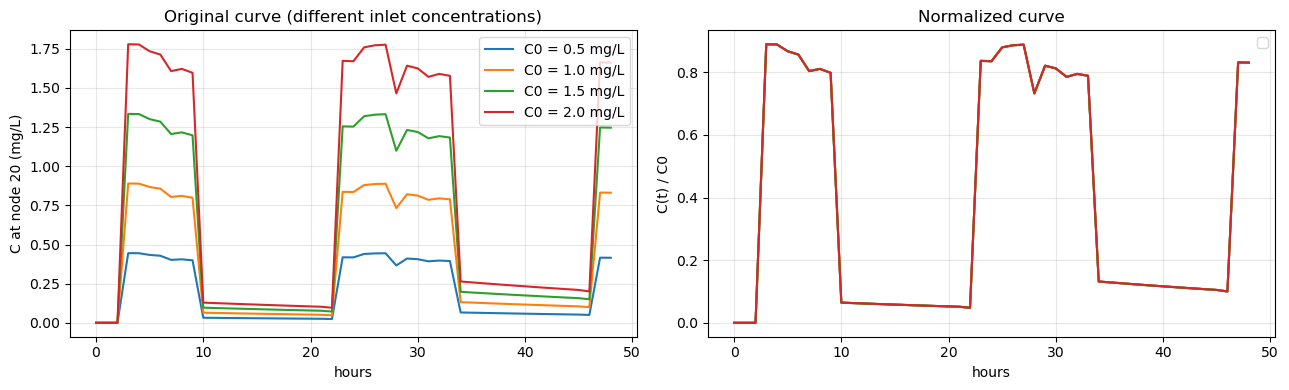

In [12]:
# === 你的代码 ===

C0_values = [0.5, 1.0, 1.5, 2.0]
probe_node = '20'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- 左图: 原始曲线 ---
for C0 in C0_values:
    # TODO 1: 跑一次模拟，参数固定 kb=-0.5, kw=-0.1, inlet_mgl 用循环变量 C0
    #         查 Setup cell 里 simulate_chlorine() 的函数签名
    ts = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, inlet_mgl=C0)
    axes[0].plot(ts.index, ts[probe_node], label=f'C0 = {C0} mg/L')
axes[0].set_xlabel('hours'); axes[0].set_ylabel(f'C at node {probe_node} (mg/L)')
axes[0].set_title('Original curve (different inlet concentrations)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- 右图: 归一化曲线 ---
for C0 in C0_values:
    ts = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, inlet_mgl=C0)   # 同上面一样的模拟调用
    # TODO 2: 在 axes[1] 上画 C(t)/C0 的曲线（应该叠合成一条）
    #         提示：x 用 ts.index, y 用 ts[probe_node] / C0
    axes[1].plot(ts.index, ts[probe_node] / C0)
axes[1].set_xlabel('hours'); axes[1].set_ylabel(f'C(t) / C0')
axes[1].set_title('Normalized curve')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### ✏️ 你的发现
- 4 条归一化曲线**完美叠合**了吗？（应该 yes）
- 如果非完美叠合，可能是什么原因？（提示：tank 的初始浓度并未随 C₀ 改变 → warmup 期会有微小差异）
- 对 Bristol 项目：这意味着只要 DMA inlet 用真实测量值，下游响应**不会因为 inlet 的绝对水平改变而失真**——参数 (k_b, k_w) 是浓度独立的。✓


---
## 练习 3 · Mass Transfer：管径变化与壁面衰减

> **导师原题**: Halve every pipe diameter. Wall decay should bite harder — why? (hydraulic radius / mass transfer; EPANET manual Ch.3).

本练习分两部分，逐步揭示一个**论文级别的重要陷阱**：

| 子题 | 改动 | 你会观察到 | 教训 |
|------|------|----------|------|
| **3.1** | 所有管径 × **0.5** | 网络水力崩溃，部分节点 = 0 | 暴力改物理参数会破坏可行性 |
| **3.2** | 所有管径 × **0.8** | 温和下降，符合预期 | 这才是 mass transfer 的真正信号 |

### 中文背景

EPANET 的 wall decay 不是直接乘到方程里的，而是通过 **mass transfer**（传质）耦合：

```
有效壁面衰减率 k_w_eff = k_w · k_f / (k_w + k_f) · (4 / D)
                                                  ↑
                                            管径越小，这一项越大
```

- D 是管径，4/D 是 **比表面积**（surface area per unit volume）
- 小管 → 单位水体接触更多管壁 → 壁面反应贡献变大
- 这就是**为什么旧的、细的、生物膜重的支管壁面衰减强**

### 学习目标

- 理解"k_w 的影响 ∝ 1/D"
- **这是 thesis 中"DMA 异质性"的物理基础**：不同 DMA 主管管径不同 → k_w 影响不同
- ⚠️ 学会**区分**：你观察到的下游变化，是化学效应还是水力效应？

---

### 3.1 · 暴力版：所有 pipe 管径 × 0.5

照搬导师题目，把每个 pipe 的 diameter 减半。

⚠️ **执行前先思考**：管径减半会让横截面积减少到原来的 1/4。
按 EPANET 的水力计算，同样的流量需要 4 倍流速 → 16 倍水头损失。
你预测哪些节点会"取不到水"？


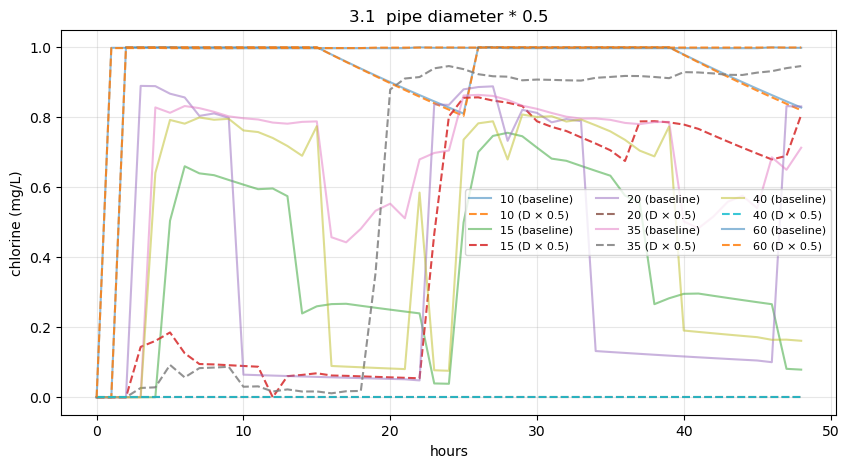

,baseline (mg/L),D * 0.5 (mg/L),drop (mg/L),drop (%)
name,,,,
10,0.955,0.953,0.002,0.200000
15,0.470,0.766,-0.296,-62.900002
20,0.440,0.000,0.440,100.000000
35,0.727,0.920,-0.193,-26.500000
40,0.541,0.000,0.541,100.000000
60,0.997,0.999,-0.002,-0.200000


In [13]:
# === 3.1 · 所有 pipe 管径 × 0.5（暴力版） ===

def halve_diameters(wn):
    """Halve every pipe diameter (pre_run hook)."""
    for pname in wn.pipe_name_list:
        pipe = wn.get_link(pname)
        pipe.diameter *= 0.5

ts_base_31 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
ts_half_31 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, pre_run=halve_diameters)

fig, ax = plt.subplots(figsize=(10, 5))
for n in MONITOR_NODES:
    ax.plot(ts_base_31.index, ts_base_31[n], '-',  alpha=0.5, label=f'{n} (baseline)')
    ax.plot(ts_half_31.index, ts_half_31[n], '--', alpha=0.85, label=f'{n} (D × 0.5)')
ax.set_xlabel('hours'); ax.set_ylabel('chlorine (mg/L)')
ax.set_title('3.1  pipe diameter * 0.5')
ax.legend(ncol=3, fontsize=8); ax.grid(alpha=0.3)
plt.show()

diff_31 = pd.DataFrame({
    'baseline (mg/L)' : ts_base_31.iloc[-24:].mean().round(3),
    'D * 0.5 (mg/L)'  : ts_half_31.iloc[-24:].mean().round(3),
    'drop (mg/L)'     : (ts_base_31.iloc[-24:].mean() - ts_half_31.iloc[-24:].mean()).round(3),
    'drop (%)'        : ((1 - ts_half_31.iloc[-24:].mean() / ts_base_31.iloc[-24:].mean()) * 100).round(1),
})
diff_31


### ✏️ 3.1 的观察

跑完 3.1 后你应该看到：

- **node 20 / 40 浓度接近或等于 0** → 这些节点根本没拿到水
- **node 15 / 35 反而升高** → 流路被重构，水绕开了 tank
- 曲线极度不规则，有"断点"和"跳变" → 网络处于**水力不可行**状态

### 为什么这么乱？

把所有管径减半同时改变了两件事：

```
1. 水力学（HYDRAULICS）            ← 主导效应！
   - 横截面积 ÷ 4
   - 同样流量要 4 倍流速
   - 水头损失 ∝ v² → ×16 倍
   - 部分节点压力变负 → 取不到水
   - 流路被重构 (水改道)

2. 水质学（WATER QUALITY）         ← 题目原本想让你看的
   - 比表面积 4/D 翻倍
   - wall decay 强度变成 ~2 倍
```

**(1) 的破坏太大，把 (2) 的信号完全淹没了。** 你"看到"的不是 wall decay，而是水力崩溃。

> 📌 **论文级教训**：在 EPANET 里改任何物理参数（管径、糙率、tank 容积…）时
> **必须同时检查水力可行性**（压力是否变负？流速是否离谱？需水是否被满足？）。
> 否则你测到的"化学效应"其实是水力效应的混淆。

---

### 3.2 · 缓和版：所有 pipe 管径 × 0.8

减小 20% 而非减半，避免水力崩溃，让 wall decay 的信号"露出来"。

直接看下一个 cell 的代码 + 结果，对比 3.1 看差异。


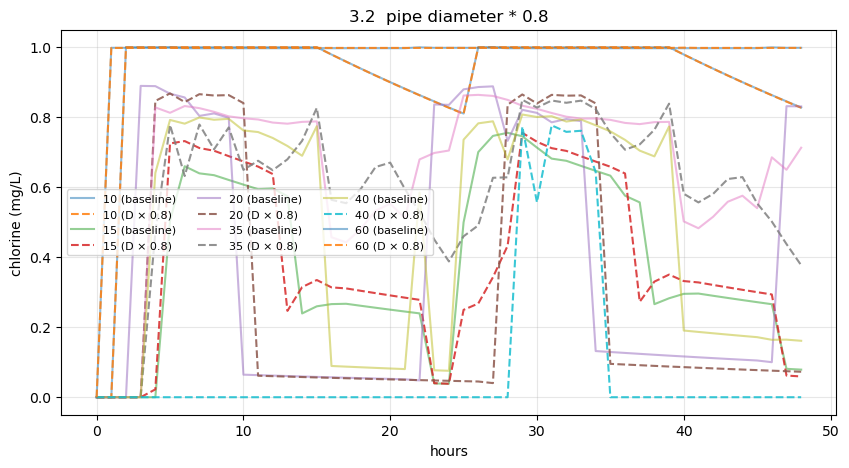

,baseline (mg/L),D * 0.8 (mg/L),drop (mg/L),drop (%)
name,,,,
10,0.955,0.955,0.000,0.000000
15,0.470,0.422,0.048,10.300000
20,0.440,0.303,0.137,31.200001
35,0.727,0.661,0.066,9.100000
40,0.541,0.178,0.363,67.099998
60,0.997,0.998,-0.001,-0.100000


In [14]:
# === 3.2 · 所有 pipe 管径 × 0.8（缓和版） ===

def shrink_diameters_80(wn):
    """Reduce every pipe diameter by 20% (pre_run hook)."""
    for pname in wn.pipe_name_list:
        pipe = wn.get_link(pname)
        pipe.diameter *= 0.8

ts_base_32 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
ts_thin_32 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, pre_run=shrink_diameters_80)

fig, ax = plt.subplots(figsize=(10, 5))
for n in MONITOR_NODES:
    ax.plot(ts_base_32.index, ts_base_32[n], '-',  alpha=0.5, label=f'{n} (baseline)')
    ax.plot(ts_thin_32.index, ts_thin_32[n], '--', alpha=0.85, label=f'{n} (D × 0.8)')
ax.set_xlabel('hours'); ax.set_ylabel('chlorine (mg/L)')
ax.set_title('3.2  pipe diameter * 0.8')
ax.legend(ncol=3, fontsize=8); ax.grid(alpha=0.3)
plt.show()

diff_32 = pd.DataFrame({
    'baseline (mg/L)' : ts_base_32.iloc[-24:].mean().round(3),
    'D * 0.8 (mg/L)'  : ts_thin_32.iloc[-24:].mean().round(3),
    'drop (mg/L)'     : (ts_base_32.iloc[-24:].mean() - ts_thin_32.iloc[-24:].mean()).round(3),
    'drop (%)'        : ((1 - ts_thin_32.iloc[-24:].mean() / ts_base_32.iloc[-24:].mean()) * 100).round(1),
})
diff_32

### ✏️ 3.2 的观察 + 3.1/3.2 综合发现

跑完 3.2 后你应该看到：

- **近源点（node 10, 60）几乎不变** ← 水太新鲜，wall decay 来不及作用
- **中距点（node 15, 35）小幅下降 ~10%** ← 物理可解释
- **远端点（node 20）较大下降 ~30%** ← 累积停留时间长 + 管壁面积/体积比变大
- **远端支管（node 40）大跌 ~67%** ← 仍有部分水力影响（小管 + 长路径双重加成）
- 曲线**整体平滑**，没有断点跳变 → 网络在水力可行域内

| 测点 | 3.1 (×0.5) | 3.2 (×0.8) | 解读 |
|------|-----------|-----------|------|
| node 10 / 60 | 几乎不变 | 几乎不变 | 紧贴 reservoir，wall decay 信号弱 |
| node 15 / 35 | 反而升高 (流路重构) | 小幅下降 (~10%) | 3.1 是水力效应，3.2 是化学效应 |
| node 20 | 归零 (断流) | 中等下降 (~30%) | 3.1 = 网络坏，3.2 = 物理可解释 |
| node 40 | 归零 (断流) | 大跌 (~67%) | 3.1 = 完全坏，3.2 = 仍有部分水力混杂 |

### 对你 thesis 的真正教训

1. **改物理参数前，永远检查水力可行性**
   - 跑完 sim 后看 `result.node['pressure'].min().min()` —— 不应该有负值
   - 看 `result.link['velocity'].max().max()` —— 一般 < 3 m/s

2. **校准 k_w 时，绝对不要改管径**
   - 管径是网络拓扑的**固有属性**（来自 Bristol 实地资料）
   - 不是可调参数
   - 你要校准的是**本征 k_w（每单位面积的反应速率）**，不是"k_w + 水力混杂"

3. **Wall-decay heterogeneity 的来源** —— 这是导师邮件强调的核心
   - 即使 3 个 DMA 的本征 k_w 完全相同
   - 由于管径分布不同（细管多 vs 粗管多），EPANET 看到的 k_w_eff 会差几倍
   - 所以**per-DMA 校准 k_w_eff 是必须的**，不能用全局一个值

---
## 练习 4 · Time-Varying Inlet：让源头浓度随时间变化

> **导师原题**: Use `wn.add_source()` with a pattern to make the inlet vary over time, mimicking a real inlet-monitor trace. This is exactly the boundary you'll impose later.

### 中文背景
真实的 Bristol DMA 入口浓度**不是常数**——白天处理厂出厂高、夜里低，还有运行波动。
WNTR 用 **add_source + pattern** 机制把"时间序列"喂进模型：

```python
wn.add_pattern('inlet_pattern', [1.0, 1.1, 0.9, 1.0, ...])    # 一系列乘数
wn.add_source('src_id', 'River', 'CONCEN', 1.0, 'inlet_pattern')   # 在 River 注入
```

- `CONCEN` 表示按浓度（mg/L）注入
- pattern 的步长 = `pattern_timestep`（默认 1h）
- 真实数据：把 SCADA 测的 C(t) 转成 pattern 喂进去

### 学习目标
- 学会用 `add_source` + `add_pattern` 配置**时变边界**
- 这就是 Bristol 项目中 DMA 入口的建模方式

### 任务
1. 构造一个 48 h 的入口浓度 pattern：白天 1.2 mg/L、夜间 0.8 mg/L（模拟一个简单的日变化）
2. 写 `pre_run` 函数把 pattern 注入到 reservoir
3. 跑仿真，对比"常数入口"和"时变入口"的下游响应
4. 应该看到：下游也呈现**日波动**，但**滞后 + 衰减**


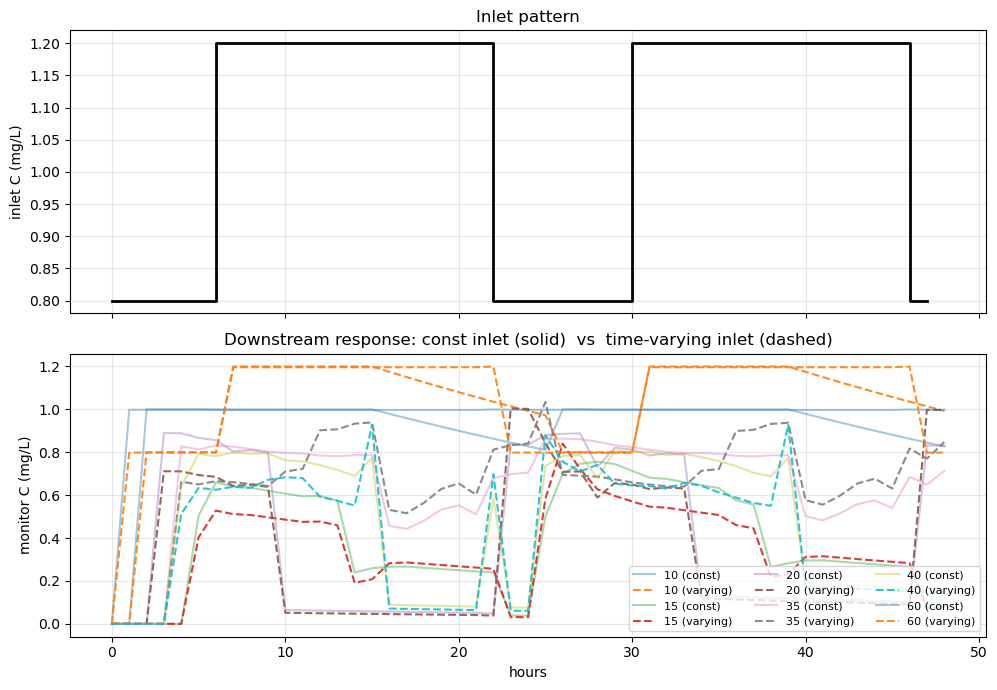

In [15]:
# === 你的代码 ===

# 1) 构造一个简单的日变化 pattern：白天高、夜间低
inlet_pattern_values = []
for hour in range(48):
    h_of_day = hour % 24
    if 6 <= h_of_day < 22:
        inlet_pattern_values.append(1.2)
    else:
        inlet_pattern_values.append(0.8)

def add_timevarying_inlet(wn):
    """把时变 inlet 注入到所有 reservoir."""
    # ① 注册 pattern：name='inlet_pat'，值序列 = inlet_pattern_values
    wn.add_pattern('inlet_pat', inlet_pattern_values)
    # ② 给每个 reservoir 加 source，C(t) = 1.0 × pattern(t)
    for r in wn.reservoir_name_list:
        wn.add_source(f'src_{r}', r, 'CONCEN', 1.0, 'inlet_pat')

# 跑两次：常数 vs 时变
ts_const = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, inlet_mgl=1.0)
ts_vary  = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, inlet_mgl=1.0,
                              pre_run=add_timevarying_inlet)

# 画图
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].step(range(48), inlet_pattern_values, where='post', lw=2, color='k')
axes[0].set_ylabel('inlet C (mg/L)'); axes[0].set_title('Inlet pattern')
axes[0].grid(alpha=0.3)

for n in MONITOR_NODES:
    axes[1].plot(ts_const.index, ts_const[n], '-',  alpha=0.4, label=f'{n} (const)')
    axes[1].plot(ts_vary.index,  ts_vary[n],  '--', alpha=0.9, label=f'{n} (varying)')
axes[1].set_xlabel('hours'); axes[1].set_ylabel('monitor C (mg/L)')
axes[1].set_title('Downstream response: const inlet (solid)  vs  time-varying inlet (dashed)')
axes[1].legend(ncol=3, fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### ✏️ 你的发现
- 下游监测点是否也出现日波动？滞后多少小时？_______________
- 离源越远的点，波动是否被"平滑"了？（→ tank 起缓冲作用）_______________
- **对 Bristol**：这就是你之后建模的**第一步**——把 SCADA 的 inlet C(t) 序列变成 pattern 喂进 EPANET。


---
## 练习 5 · Brute-Force Calibrator：第一个"校准"算法

> **导师原题**: Loop `simulate_chlorine()` over a `(kb, kw)` grid and compute the sum of squared errors against a synthetic "observed" run.

### 中文背景
这是 **GLUE / Bayesian 之前最朴素的校准**：
1. 选定一个"真值" `(k_b*, k_w*)` 当作 synthetic truth
2. 把它的模拟结果当"观测"
3. 在 (k_b, k_w) 网格上扫描，每个组合算 SSE = Σ(C_sim - C_obs)²
4. 找最小 SSE 的格点 → 这就是粗校准的 (k_b̂, k_ŵ)

### 学习目标
- 理解校准的本质：**枚举参数 + 比较与观测的差距**
- 亲眼看到 **identifiability 问题**：误差地形上可能有一条"沟"而不是一个点（→ Plan B Bayesian 才能给完整的 trade-off 图景）

### 任务
1. 用 `(k_b=-0.5, k_w=-0.2)` 跑一次当作"observed"
2. 在 `k_b ∈ [-1.0, 0]` × `k_w ∈ [-0.6, 0]` 的 9×9 网格上扫描
3. 每个格点算 SSE（去掉 warmup 期，例如前 24 h）
4. 画热力图找最小值
5. 检查：最小值是否对应 (-0.5, -0.2)？还是一条沟？


网格扫描中...
  row 1/9 done
  row 2/9 done
  row 3/9 done
  row 4/9 done
  row 5/9 done
  row 6/9 done
  row 7/9 done
  row 8/9 done
  row 9/9 done


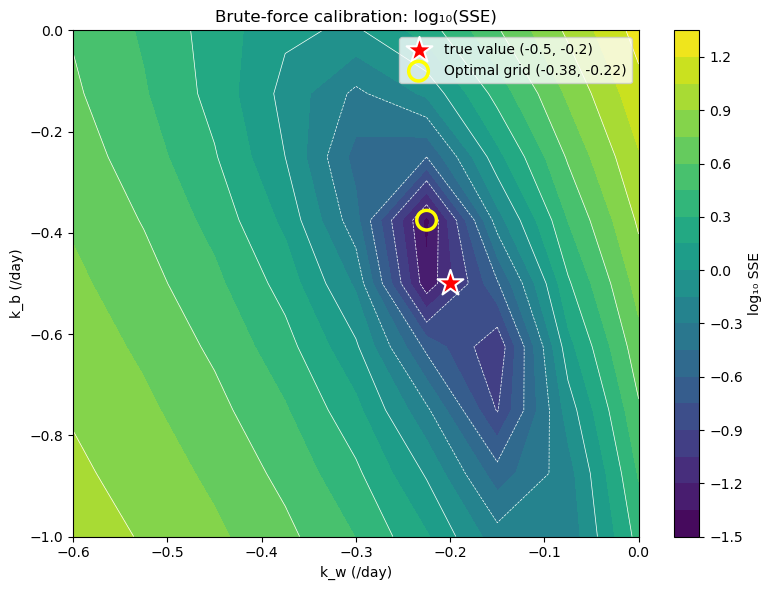

true value : kb=-0.5,  kw=-0.2
estimated : kb=-0.375, kw=-0.225


In [16]:
# === 你的代码 ===

# Step 1: 合成 "观测" (synthetic truth)
TRUE_KB, TRUE_KW = -0.5, -0.2
ts_obs = simulate_chlorine(kb_per_day=TRUE_KB, kw_per_day=TRUE_KW, duration_hours=72)
WARMUP_H = 24
obs = ts_obs.iloc[WARMUP_H:]   # 丢弃 warmup

# Step 2: 设定网格
kb_grid = np.linspace(0.0, -1.0, 9)
kw_grid = np.linspace(0.0, -0.6, 9)
SSE = np.full((len(kb_grid), len(kw_grid)), np.nan)

# Step 3: 扫描
print('网格扫描中...')
for i, kb in enumerate(kb_grid):
    for j, kw in enumerate(kw_grid):
        # TODO 1: 用当前的 (kb, kw) 跑一次模拟，duration_hours=72
        ts = simulate_chlorine(kb_per_day=kb, kw_per_day=kw, duration_hours=72)
        # 丢弃 warmup
        sim = ts.iloc[WARMUP_H:]
        # TODO 2: 计算 SSE = 所有 monitor、所有时间步上 (sim - obs) 平方的总和
        # 提示：
        #   sim 和 obs 都是 DataFrame (rows=时间, cols=monitor)
        #   两个 DataFrame 相减得到一个 DataFrame
        #   .sum() 默认按列求和 → Series；再 .sum() → 标量
        SSE[i, j] = ((sim - obs) ** 2).sum().sum()
    print(f'  row {i+1}/{len(kb_grid)} done')

# Step 4: 画热力图
fig, ax = plt.subplots(figsize=(8, 6))
KW, KB = np.meshgrid(kw_grid, kb_grid)
cf = ax.contourf(KW, KB, np.log10(SSE + 1e-9), levels=20, cmap='viridis')
ax.contour(KW, KB, np.log10(SSE + 1e-9), levels=8, colors='white', linewidths=0.5)
ax.scatter([TRUE_KW], [TRUE_KB], marker='*', s=380, c='red', edgecolors='white',
           linewidths=1.5, zorder=10, label=f'true value ({TRUE_KB}, {TRUE_KW})')

# 标记估计的最小值
idx_min = np.unravel_index(np.nanargmin(SSE), SSE.shape)
kb_hat, kw_hat = kb_grid[idx_min[0]], kw_grid[idx_min[1]]
ax.scatter([kw_hat], [kb_hat], marker='o', s=200, facecolors='none',
           edgecolors='yellow', linewidths=2.5, zorder=11,
           label=f'Optimal grid ({kb_hat:.2f}, {kw_hat:.2f})')

ax.set_xlabel('k_w (/day)'); ax.set_ylabel('k_b (/day)')
ax.set_title('Brute-force calibration: log₁₀(SSE)')
ax.legend(); plt.colorbar(cf, ax=ax, label='log₁₀ SSE')
plt.tight_layout(); plt.show()

print(f'true value : kb={TRUE_KB},  kw={TRUE_KW}')
print(f'estimated : kb={kb_hat:.3f}, kw={kw_hat:.3f}')


### ✏️ 你的发现
- 网格估计的 (k_b̂, k_ŵ) 是否接近真值 (-0.5, -0.2)？_______________
- 误差地形是**一个清晰的点**，还是**一条对角线"沟"**？（提示：这就是 identifiability 问题）_______________
- 如果是一条沟，单点估计可信吗？_______________

### 🔮 引出 Plan A / Plan B
- **Plan A (GLUE)**：不报告单点，而是**保留所有 SSE < 阈值的格点**作为"behavioral simulations" → 它们一起代表参数不确定性
- **Plan B (Bayesian MCMC)**：用 likelihood `L ∝ exp(-SSE/(2σ²))` 把 SSE 转成概率分布 → 给出 `p(k_b, k_w | data)` 的完整后验
- 两者都是这个 Exercise 5 的**升级版**——但你必须先理解这个"裸"基线

---

## 🎓 完成检查清单

完成所有 5 题后回顾：

| ✓ | 内容 | 我学到了什么 |
|---|------|------------|
| ☐ | 练习 1 | k_b 和 k_w 各贡献多少损失；哪个 monitor 对 k_w 最敏感 |
| ☐ | 练习 2 | 一阶动力学的线性性质 → 入口可作为边界条件 |
| ☐ | 练习 3 | 管径影响壁面有效衰减 → DMA 异质性的物理根源 |
| ☐ | 练习 4 | 用 add_source + pattern 实现时变边界 → Bristol 建模必备 |
| ☐ | 练习 5 | 校准的本质 = 枚举 + 误差最小化；identifiability 问题为何存在 |

## 📌 接下来的事

完成后，你已经具备从"理解 EPANET" → "做 Bristol 真实 case"的**全部基础工具**。

下一步推荐顺序（见 `plan1.md`）：
1. 拿到 Bristol 3-DMA `.inp` 文件，替换 `PRACTICE_INP`
2. 拿到 10 个 monitor ID，替换 `MONITOR_NODES`
3. 拿到 SCADA 的 inlet C(t)，用练习 4 的方法注入
4. 复刻练习 5 的网格扫描——但这次"observed" 是真实测量值
5. 把网格扫描升级为 GLUE（保留所有 SSE < 阈值的样本）
6. 再升级为 Bayesian（MCMC + 完整后验）

加油！🚀
